# Compare the peak to trough ratios of our deconvolution runs

1. Load the model 
2. Load the raw data
3. Load the deconvolved data
4. Compute the peak to trough ratio
5. Load the published peak to trough ratio values
6. Plot the comparison between the peak to trough ratios


In [2]:
# Preamble, notebook setup and imports

%load_ext autoreload
%autoreload 2
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import os


In [3]:
from cc_src.deconvolution_analysis import DeconvolvedAnalysis
from src.config import Config, load_xg_gene_expression_config
from src.model import Model

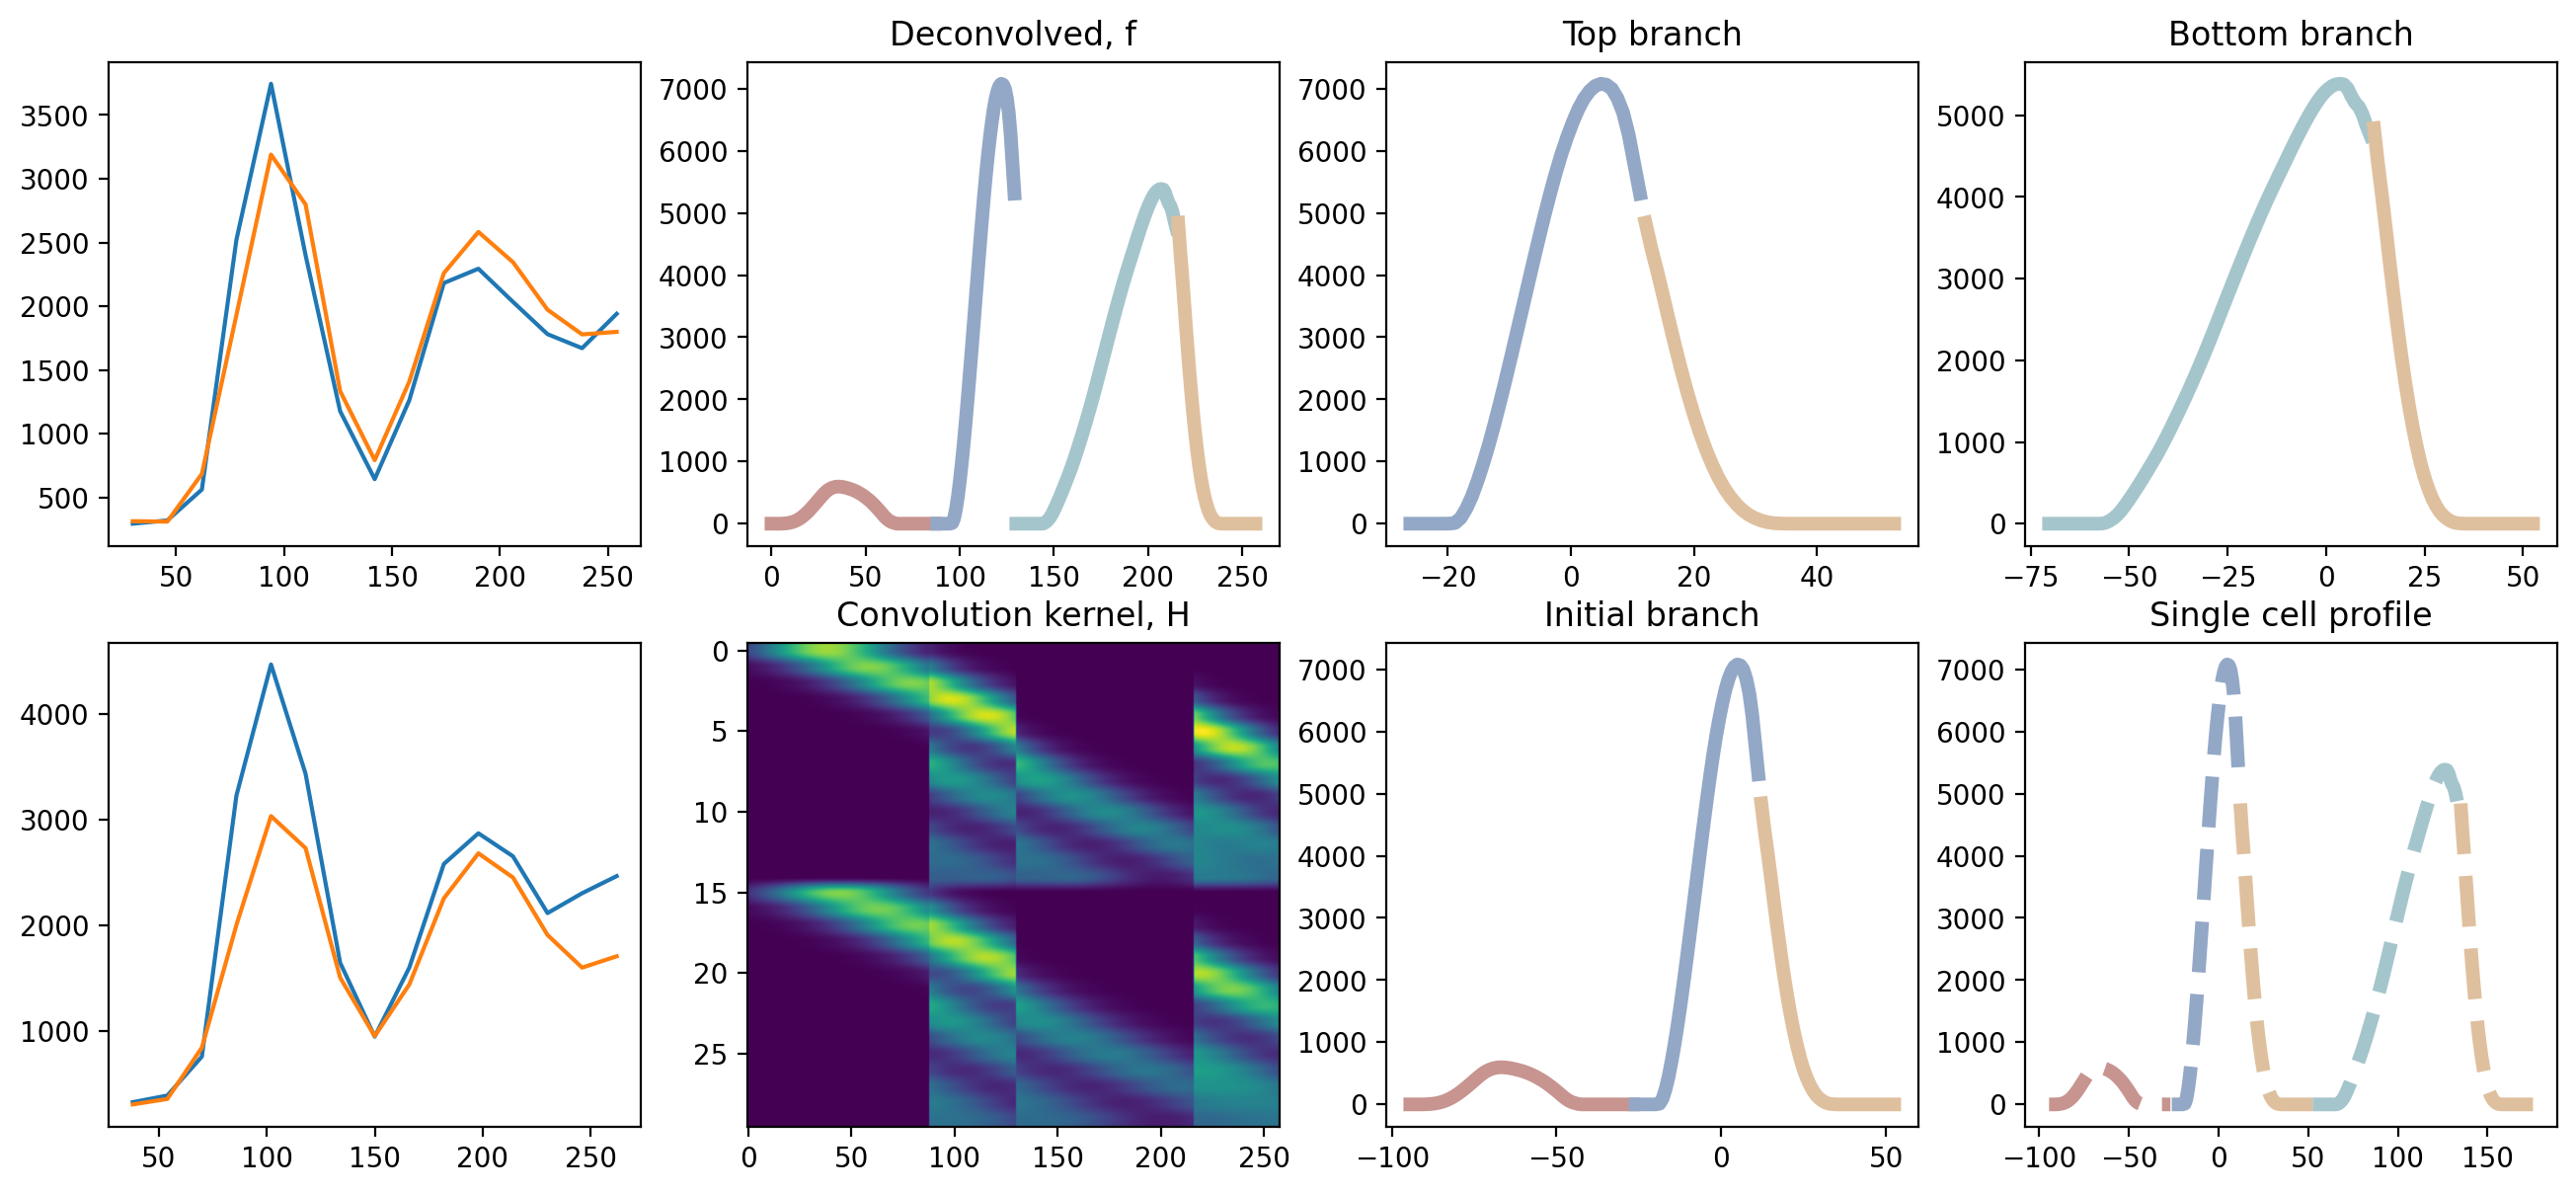

In [26]:
from cc_src.sgd import get_orfname

gene_name = 'CLN2'
orf_name = get_orfname(gene_name)
gamma = 0.004

config = load_xg_gene_expression_config()
model = Model(config, gene_name, gamma)

deconvolved_analysis = DeconvolvedAnalysis(model)
deconvolved_analysis.plot_deconvolved_gene(gene_name)

In [12]:
genelist = pd.read_csv('allgenes/commongenelist.txt',sep='\t', header=None)[0].values

In [28]:
gene_f = deconvolved_analysis.f.loc[orf_name].values

In [46]:
def combine_ptr_score(c, d, weight):
    score = np.power(c, weight)*np.power(d, 1-weight);
    return score

array([ 88,  89,  90,  91,  92,  93,  94,  95,  96,  97,  98,  99, 100,
       101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113,
       114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126,
       127, 128, 129, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225,
       226, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 237, 238,
       239, 240, 241, 242, 243, 244, 245, 246, 247, 248, 249, 250, 251,
       252, 253, 254, 255, 256, 257])

In [122]:
cg1_indices = np.concatenate([model.config.phase_columns['CG1'], 
                              model.config.phase_columns['postG1']])
dg1_indices = np.concatenate([model.config.phase_columns['DG1'], 
                              model.config.phase_columns['postG1']])

cg1_f = gene_f[cg1_indices]
dg1_f = gene_f[dg1_indices]

cg1_20, cg1_80 = np.quantile(cg1_f, [0.2, 0.8])
dg1_20, dg1_80 = np.quantile(dg1_f, [0.2, 0.8])

cg1_20 = max(cg1_20, 1)
dg1_20 = max(dg1_20, 1)

# Need to normalize/timepoint scale.

weight = 2./3.;
cptr = cg1_80/cg1_20;
dptr = dg1_80/dg1_20;

combinedPtr = combine_ptr_score(cptr, dptr, weight)
combinedPtr


4838.933550565073

In [114]:
np.quantile(cg1_f, [0.2, 0.8])

array([  28.16927118, 6580.91839112])

In [116]:
np.quantile(cg1_f, [.2, 0.8])

array([  28.16927118, 6580.91839112])

In [54]:
d = deconvolved_analysis.f.reset_index()
d[d.orf_name == orf_name]

,orf_name,0,1,2,3,4,5,6,7,8,...,248,249,250,251,252,253,254,255,256,257
2097,YPL256C,0.051163,0.02776,0.03887,0.000021,0.000026,0.55444,1.887946,3.949899,6.960726,...,0.000004,0.000004,0.000002,0.000002,0.000005,0.000007,0.000003,0.000002,0.000003,0.000003


In [94]:
matlab_fs = pd.read_csv('../deconvolution-project/output/2023-11-27_xg_deconv2_gammas/'\
                        'all_genes_f.csv', header=None)
matlab_gs.index = deconvolved_analysis.f.index
matlab_gs = pd.read_csv('../deconvolution-project/output/2023-11-27_xg_deconv2_gammas/'\
                        'all_genes_g.csv', header=None)
matlab_fs.index = deconvolved_analysis.f.index

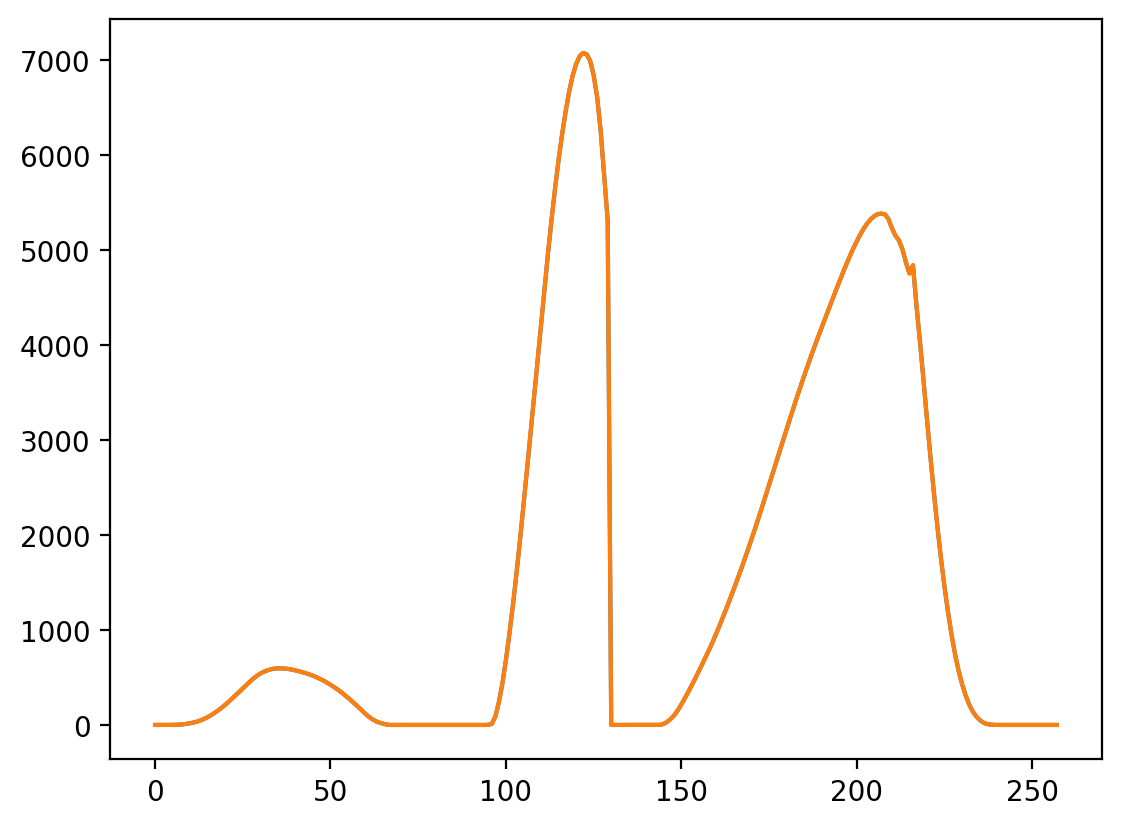

In [97]:
matlab_f = matlab_fs.loc[orf_name]
plt.plot(matlab_f)
plt.plot(gene_f)

In [103]:
gene_table_path = '/Users/trung/Research/cell-cycle/data/dataset_from_deconv_web/gene_associated.tsv';
gene_table = pd.read_csv(gene_table_path, sep='\t');
gene_table = gene_table[['Systematic Name', 'Deconvolved PTR (80pt/20pt)']].set_index('Systematic Name')
gene_table.head(2)

,Deconvolved PTR (80pt/20pt)
Systematic Name,
YKR013W,14716.721
YIL140W,7425.072


In [104]:
gene_table.loc[orf_name]

Deconvolved PTR (80pt/20pt)    4808.477
Name: YPL256C, dtype: float64